In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
%matplotlib inline
import h5py
from sklearn.decomposition import PCA
from getdist import MCSamples, plots
from scipy.stats import norm
from numpy import linalg as la

plt.rcParams['figure.figsize'] = (3.5, 2.5)

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'
matplotlib.rcParams['text.usetex'] = False

colors = [
    "#1b5f6f",  # dark teal
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#882255",  # wine
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#999999",  # grey
    "#117733",  # dark green
]

In [2]:
path = '/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'

survey = 'roman'

class SURVEY:
    def __init__(self,survey):
        self.survey = survey

    # Global parameters
    def nz_params(self):
        if self.survey == 'des':
            Nz = 299 #len(z)
            Nt = 4
        elif self.survey == 'roman':   
            Nz = 46 #len(z)
            Nt = 9
        return Nz,Nt

    def get_nzs(self):
        Nz,Nt = self.nz_params()
        if self.survey == 'des':
            nz = f'{path}/roman_nz_realizations/Fisher_matrix/Tz_realizations_WZ_bq_pile3_0d01.npy' # shared by Boyan Yin
            nz = np.load(nz)             ## shape = (10095, 4, 300) = (Ns, Nt, Nz) = (# of simulations, # of tomo bins, # of redshift)
            nz = nz[:,:,1:]              ## shape = (10095, 4, 299) | (first :) => all 10095 simulations, (second :) => all 4 tomo bins, (third ,1:) => all redshift bins except the first where nz is 0.0.
            Ns = np.shape(nz)[0]         ## Number of simulations: 10095
            nz = nz.reshape(Ns, Nt * Nz) ## shape = (10095, 1196) = (Ns, Nt*Nz)
            min_z   = 0.01
            max_z   = 3
            delta_z = (max_z - min_z) / Nz
            zbins   = np.arange(min_z,max_z+delta_z,delta_z)
            z  = zbins[:-1]+(zbins[1]-zbins[0])/2.
            return z, nz

        elif self.survey == 'roman':
            sc = 'sc3b_d4'
            nz = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')
            z = np.array(nz['zbinsc'])
            return z, nz

    def cov_of_ndiff(self):
        Nz,Nt = self.nz_params()
        z,nz = self.get_nzs()

        if self.survey == 'roman':
            r = 500 # hundreds/thousands out of 1M realizations
            np.random.seed(42)
            sims_indexes = np.random.randint(1, 10**6 + 1, size=r)
            tot = len(sims_indexes)

            rows = []
            for j in sims_indexes:
                row = []
                for i in range(Nt):
                    normalized = nz[f'bin{i}'][j] / np.trapz(y=nz[f'bin{i}'][j], x=z)
                    row.append(normalized)
                rows.append(np.hstack(row))

            nz = np.vstack(rows)
            nbar = np.mean(nz,axis=0)
            ndiff = nz - nbar
            Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff
        elif self.survey == 'des':
            nbar = np.mean(nz,axis=0)
            ndiff = nz - nbar
            Cn = np.einsum('ij,ik->jk',ndiff,ndiff) / (ndiff.shape[0]-1) # equivalent to Cn = ndiff.T @ ndiff
        return Cn, ndiff

    # Unweighted PCA    
    def pcs(self,method='eig'):
        #Cn = np.load(f'{path}/codes/Cn_roman_sc1bd4.npy') #TODO: path changed
        Nz,Nt = self.nz_params()
        Nd = Nz*Nt
        Cn,_ = self.cov_of_ndiff()
        Cn = 0.5*(Cn + Cn.T)
        if method == 'eig':
            eigvals, eigvecs = np.linalg.eig(Cn)
        elif method == 'eigh':
            eigvals, eigvecs = np.linalg.eigh(Cn)
        elif method == 'svd':    
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'sklearn':
            pca = PCA()
            pca.fit(Cn)
            eigvecs, eigvals = pca.components_, pca.singular_values_
            explained_variance = pca.explained_variance_
            explained_variance_ratio = pca.explained_variance_ratio_
        ######
        if method != 'sklearn':
            eigvals = np.real(eigvals)
            eigvecs = np.real(eigvecs)
            idx     = np.argsort(eigvals)[::-1] # 1. Get indices to sort eigenvalues in descending order
            eigvals = eigvals[idx]              # 2. Sort eigenvalues (largest to smallest)
            eigvals = np.maximum(0,eigvals)     # 3. Clamp any small negative eigenvalues to 0 (often due to numerical errors)
            eigvecs = eigvecs[:, idx]           # 4. Reorder columns of eigenvectors to match sorted eigenvalues
            return eigvecs, eigvals
        elif method == 'sklearn':
            return eigvecs.T, eigvals, explained_variance,explained_variance_ratio 
            
    # Credit: Gary M. Bernstein
    def nearestPD(self,A):
        """Find the nearest positive-definite matrix to input
        A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
        credits [2].
        [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
        [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
        matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
        """
        B = (A + A.T) / 2
        _, s, V = np.linalg.svd(B)
        H = np.dot(V.T, np.dot(np.diag(s), V))
        A2 = (B + H) / 2
        A3 = (A2 + A2.T) / 2
        if self.isPD(A3):
            return A3
        spacing = np.spacing(np.linalg.norm(A))
        I = np.eye(A.shape[0])
        k = 1
        while not self.isPD(A3):
            mineig = np.min(np.real(np.linalg.eigvals(A3)))
            A3 += I * (-mineig * k**2 + spacing)
            k += 1
        return A3

    def isPD(self,B):
        """Returns true when input is positive-definite, via Cholesky"""
        try:
            _ = np.linalg.cholesky(B)
            return True
        except np.linalg.LinAlgError:
            return False              
    
    def getModes(self,D, Cn, chisq_threshold=0.1):
        '''Calculate the compression matrix from n to u and the
        modes U that multiply each U.  
        Parameters:
        `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
                matrix of the observables c, and J is the Jacobian dc/dn,
                shape=(N,N)
        `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
        `chisq_threshold`:  Your desired upper bound for the mean error in chisq
                resulting from the compression.
        Returns:
        `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
                covariance matrix of the u's will be the identity.
        `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
        `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
        `resid`:  Mean amount of chisq shift caused by compression.

        You can safely use fewer than `nModes` of the returned X and U if you 
        think the discarded `dchisq` values are small enough.'''

        thr = 1e-25     # Dynamic range threshold for eigenvalues

        # Symmetrize and sqrt D
        D = 0.5*(D + D.T)
        Dval, Dvec = np.linalg.eigh(D)
        # Any negatives are numerical problems
        Dval = np.maximum(0., Dval)

        # And Cn
        Cnval, Cnvec = np.linalg.eigh(Cn)
        Cnval = np.maximum(0., Cnval)

        # Build the keystone matrix and its SVD
        M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
        Um,s,Vmt = np.linalg.svd(M)

        # Sort SV's and throw away unwanted ones
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                            
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        Um = Um[:,keep]
        Vm = Vmt.T[:,keep]
        s = s[keep]

        # Build the encoder
        tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
        X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
        # And the decoder
        tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
        U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s) # Vm s
        
        return X, U, s*s, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M

# Unweighted PCA

## Roman case  

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{46}],[\text{PC}^1_{47},\text{PC}^1_{48},\cdots,\text{PC}^1_{92}],6\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{413},\cdots,\text{PC}^1_{414}]\Big]$

In [3]:
roman_obj = SURVEY('roman')
Nz,Nt = roman_obj.nz_params()
z,nz = roman_obj.get_nzs()

eig_vecs, eig_vals = roman_obj.pcs('eig')
eih_vecs, eigh_vals = roman_obj.pcs('eigh')
svd_vecs, svd_vals = roman_obj.pcs('svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = roman_obj.pcs('sklearn')

/tmp/ipykernel_3472917/2625748980.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',fontsize=12,borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

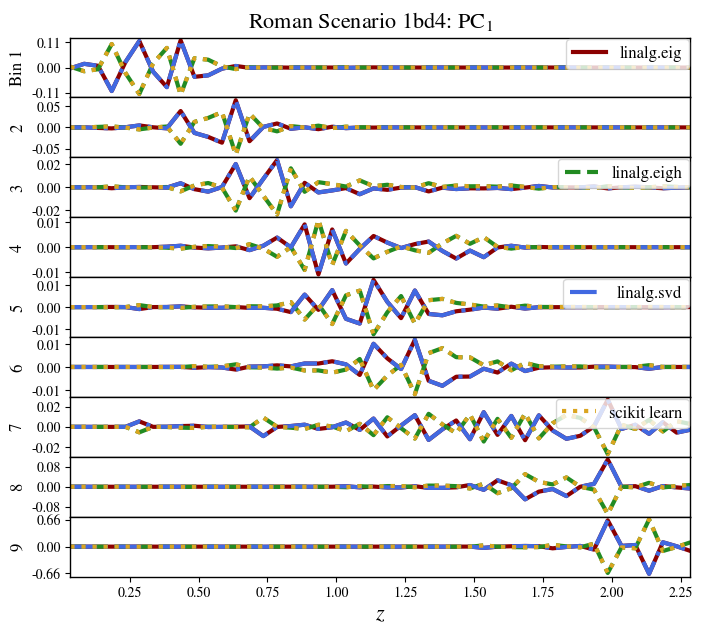

In [ ]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eig_vecs[start:end, pci],c='darkred',lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c='forestgreen',lw=3, ls='--', label='linalg.eigh' if k==2 else None)
    ax.plot(z, svd_vecs[start:end, pci],c='royalblue',lw=3, ls='-.', label='linalg.svd' if k==4 else None)
    ax.plot(z, skl_vecs[start:end, pci],c='goldenrod',lw=3, ls=':' , label='scikit learn' if k==6 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}',fontsize=12)
    ax.legend(loc='upper right',fontsize=12,borderaxespad=.1)

unused_legs = [1,3,5,7,8]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$',fontsize=16)
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", fontsize=16, y=0.92);

### Test 2 - Plot the singular values  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The singular values are the same.

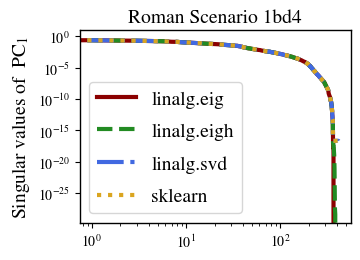

In [8]:
Ms = list(range(Nz*Nt))
plt.figure()
plt.plot(Ms,eig_vals ,c='darkred'    ,lw=3, ls='-' ,label='linalg.eig')
plt.plot(Ms,eigh_vals,c='forestgreen',lw=3, ls='--',label='linalg.eigh')
plt.plot(Ms,svd_vals ,c='royalblue'  ,lw=3, ls='-.',label='linalg.svd')
plt.plot(Ms,skl_vals ,c='goldenrod'  ,lw=3, ls=':' ,label='sklearn')
plt.xscale('log')
plt.yscale('log')
plt.ylabel(rf'Singular values of  PC$_1$',fontsize=14)
plt.title('Roman Scenario 1bd4',fontsize=14)
plt.legend(loc='best',fontsize=14);

### Test 3 - Comparing methods to get the PCs: `pcs` vs `getModes`  
The method `pcs` compute the PCs with the standard unweighted PCA. The method `getModes` compute the PCs weighted by the Fisher matrix (see 2506.00758). However, if we force $F=I$, then both methods possoes the same eigvalues, while the eigvectors differ by a factor $\Lambda_n^{1/2}P_M$. Here we show how:  
1. The eigvalues are the same:  
In Eq. 15 of 2506.00758, if $F=I$, then $G = \Lambda_n = V_G\Lambda_G V_G^T$. However, $\Lambda_n=\text{diag}[\lambda_1^n,\cdots,\lambda_N^n]$ thus $\Lambda_G=\Lambda_n$ and $V_G = I$.
2. The eivegtors differ by a scaling factor of $\Lambda_n^{-1/2}$:  
The decode matrix (eq 19/22 in 2506.00758) is $D = V_n^T\Lambda_n^{1/2}V_GP_M$. We have $V_G = I$, then $D = V_n^T\Lambda_n^{1/2}P_M$. In particular, if $M=N$, then $P_M = I$ and $D = V_n^T\Lambda_n^{1/2}$.

In [ ]:
Cn,ndiff = roman_obj.cov_of_ndiff()
D = np.identity(Cn.shape[0])

if not roman_obj.isPD(D):
    print('fixing cov')
    D=roman_obj.nearestPD(D)

X, U, ss, resid, Dvec, Dval, Cnvec, Cnval, Um, Vm, M = roman_obj.getModes(D,Cn,chisq_threshold=0);

/tmp/ipykernel_3472917/4002392084.py:181: RuntimeWarning: divide by zero encountered in divide
  tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)


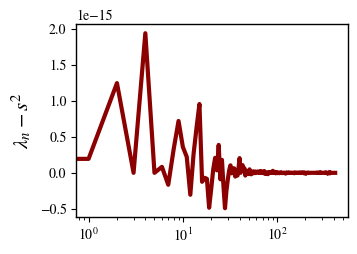

In [33]:
plt.semilogx(range(len(eig_vals)), eig_vals-ss,ls='-',c='darkred',lw=3)
plt.ylabel(r'$\lambda_n-s^2$',fontsize=15);

Text(0.5, 0, 'z')

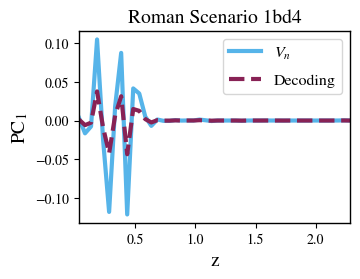

In [99]:
idx = np.argsort(Cnval)[::-1]
decoding_matrix = Cnvec[:,idx] @ np.diag(Cnval[idx]) # Eq 19/20 in 2506.00758 when M = N and Fisher = Identity
decoding_matrix2 = Cnvec[:,idx] # @ np.diag(Cnval[idx])

k=0 # tomo slice
pci=0 # PC_i, i = 1,...,414

start, end = Nz*k, Nz*(k+1)
plt.plot(z,eih_vecs[start:end,pci],c='#56B4E9',label=r'$V_n$',lw=3,ls='-')
plt.plot(z,decoding_matrix[start:end,pci],c='#882255',label='Decoding',lw=3,ls='--')
plt.xlim(np.min(z),np.max(z))
plt.legend(loc='upper right',fontsize=11.5)
plt.title('Roman Scenario 1bd4',fontsize=14)
plt.ylabel(rf'PC$_{{{pci+1}}}$',fontsize=14)
plt.xlabel('z',fontsize=14)

/tmp/ipykernel_3472917/3064271864.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right',fontsize=12,borderaxespad=.1)


<Figure size 350x250 with 0 Axes>

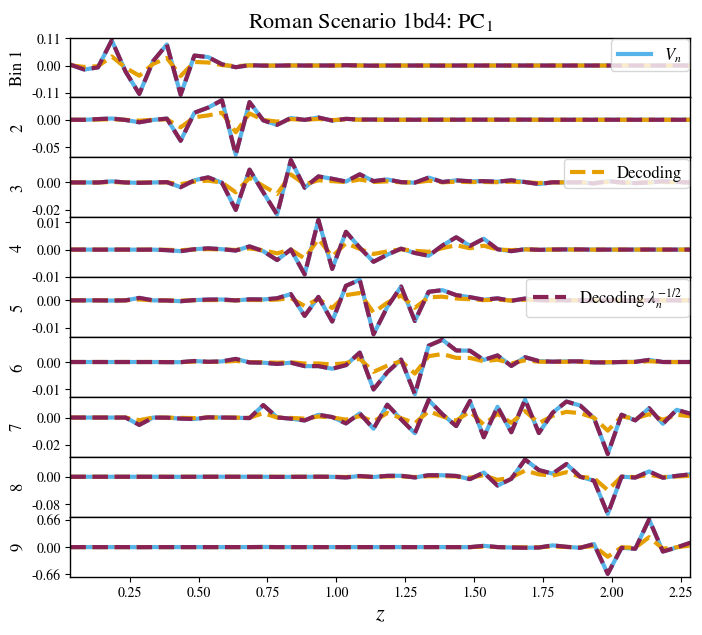

In [112]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 7),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 0

for k,ax in enumerate(axes): #k=tomo bin slice
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eih_vecs[start:end, pci],c='#56B4E9',lw=3, ls='-' , label=r'$V_n$' if k==0 else None)
    ax.plot(z, decoding_matrix[start:end, pci],c='#E69F00',lw=3, ls='--', label='Decoding' if k==2 else None)
    ax.plot(z, decoding_matrix2[start:end, pci],c='#882255',lw=3, ls='--', label=r'Decoding $\lambda_n^{-1/2}$' if k==4 else None)
    ax.set_ylabel(f'Bin {k+1}' if k==0 else f'{k+1}',fontsize=12)
    ax.legend(loc='upper right',fontsize=12,borderaxespad=.1)

unused_legs = [x for x in range(9) if x not in [0,2,4]]
for i in unused_legs:
    axes[i].get_legend().remove()

axes[k].set_xlabel(r'$z$',fontsize=16)
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"Roman Scenario 1bd4: PC$_{{{pci+1}}}$", fontsize=16, y=0.92);

## DES case

### Test 1 - Fix one PC (e.g. PC_1) and plot its slices across the tomographic bins:  
Here we test 4 different methods to obtain the PCs:   (1) linalg.eig,  (2) linagl.eigh,  (3) linalg.svd, and (4) scikit learn  
The principal components are the same, except for a possible sign flip.  
$\text{PC}^1 = \Big[[\text{PC}^1_{1},\text{PC}^1_{2},\cdots,\text{PC}^1_{299}],[\text{PC}^1_{300},\text{PC}^1_{301},\cdots,\text{PC}^1_{598}],1\times[\cdots],[\text{PC}^1_{412},\text{PC}^1_{898},\cdots,\text{PC}^1_{1196}]\Big]$

In [10]:
des_obj = SURVEY('des')
Nz,Nt = des_obj.nz_params()
z,nz = des_obj.get_nzs()

eig_vecs, eig_vals = des_obj.pcs('eig')
eih_vecs, eigh_vals = des_obj.pcs('eigh')
svd_vecs, svd_vals = des_obj.pcs('svd')
skl_vecs, skl_vals,\
explained_variance, explained_variance_ratio = des_obj.pcs('sklearn')

In [ ]:
plt.figure()
fig, axes = plt.subplots(nrows=Nt, ncols=1, sharex=True, sharey=False,figsize=(8, 4),
                        gridspec_kw={'wspace':0.0, 'hspace':0.0})
pci = 1

for k,ax in zip(range(Nt),axes):
    start, end = Nz*k, Nz*(k+1)
    max_y = np.max(eig_vecs[start:end, pci])
    min_y = np.min(eig_vecs[start:end, pci])
    d_y = (max_y - min_y) / 2
    ax.set_yticks([-d_y, 0, +d_y])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.plot(z, eig_vecs[start:end, pci],c='darkred',lw=3, ls='-' , label='linalg.eig' if k==0 else None)
    ax.plot(z, eih_vecs[start:end, pci],c='forestgreen',lw=3, ls='--', label='linalg.eigh' if k==1 else None)
    ax.plot(z, svd_vecs[start:end, pci],c='royalblue',lw=3, ls='-.', label='linalg.svd' if k==2 else None)
    ax.plot(z, skl_vecs[start:end, pci],c='goldenrod',lw=3, ls=':' , label='scikit learn' if k==3 else None)
    ax.set_ylabel(f'Bin {k+1}',fontsize=12)
    ax.legend(loc='upper right',fontsize=12,borderaxespad=.1)

axes[k].set_xlabel(r'$z$',fontsize=16)
plt.xlim(np.min(z),np.max(z))
fig.suptitle(rf"DES: PC$_{{{pci}}}$", fontsize=16, y=0.94);

In [ ]:
## The singular values are the same.  
# Here we test 4 different methods to obtain the singular values:   1 - linalg.eig,  2 - linagl.eigh,  3 - linalg.svd,  4 - scikit learn

Ms = list(range(Nz*Nt))
plt.figure()
plt.plot(Ms,eig_vals ,c='darkred'    ,lw=3, ls='-' ,label='linalg.eig')
plt.plot(Ms,eigh_vals,c='forestgreen',lw=3, ls='--',label='linalg.eigh')
plt.plot(Ms,svd_vals ,c='royalblue'  ,lw=3, ls='-.',label='linalg.svd')
plt.plot(Ms,skl_vals ,c='goldenrod'  ,lw=3, ls=':' ,label='sklearn')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Points',fontsize=14)
plt.ylabel(rf'Singular values of  PC$_1$',fontsize=14)
plt.title('DES',fontsize=14)
plt.legend(loc='best',fontsize=14);

## Lets plot how the PCs's amplitudes are distributed  
The amplitudes $\alpha_i$'s are just the projection of the original basis onto PCs: $\alpha_i^{r} =\langle\mathbf{\Delta}^{r},\mathbf{U}_i\rangle = \sum_{t=1}^{N_\text{tomo}}\sum_{k=1}^{N_z}\mathbf{\Delta}^{r}_t(z_k)\cdot \mathbf{U}_i^t(z_k)$  
OBS: Sometimes we use U to denote the PCs. $r$ is the nz realization, i.e., $r=1,\cdots,10^6$.

In [ ]:
alphas = ndiff @ eih_vecs
nEig = np.shape(alphas)[1]
print('nEig: ', nEig)

names = ["alpha%s" %i for i in range(nEig)]
labels = [rf"\alpha_{{{i}}}" for i in range(nEig)]
chains = MCSamples(samples=alphas,names=names,labels=labels)

g = plots.get_subplot_plotter(subplot_size=1)
g.triangle_plot(chains,["alpha%s" %i for i in range(3)],filled=True)

## Lets check the function that forward the modified nz to CoCoA  
More specifically, to _cosmolike_prototype_interface.py.

In [13]:
def forward_pca(nz_fid,params_values,survey,photoz_pc_file,npc):
    
    if npc == 0:
        return nz_fid

    elif npc > 0:
        U = photoz_pc_file[:,:npc] # Here is not a file, but in CoCoA is. We keep the notation.
        alphas_vals = np.array([params_values.get(survey+"_alpha_"+str(i+1)) for i in range(npc)])
        
        correction = (alphas_vals * U).sum(axis=1)

        s = nz_fid[:,1:].shape # (46,9)
        z = nz_fid[:,0]

        nz_model = nz_fid[:,1:].T.flatten() + correction # |nz_model| ~ 1 for npc << 414 and |alpha| ~< 1.
        nz_model = nz_model.reshape(s[::-1]).T
        nz_model = np.column_stack((z,nz_model))

        return nz_model

In [ ]:
# Lets assume the amplitudes are drawn a normal distribution
seed = 40 # If the seed is turned off, the plot below will be different.
rng = np.random.default_rng(seed)
dist = norm(loc=0, scale=1)
alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)

alphas_r_dict = {f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)}

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) #(46,9) -> (46,10)

plt.figure()
nrows, ncols = 1, 4
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True,figsize=(12, 2.4),
                        gridspec_kw={'wspace':0.01, 'hspace':0.0})

for npc in range(ncols):
    for k in range(Nt):
        nz_mod = forward_pca(nz_fid,alphas_r_dict,'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
        axes[npc].plot(z,nz_fid[:,k+1],'C0', label='nz_fid' if npc==0 and k==0 else None)
        axes[npc].plot(z,nz_mod[:,k+1],ls=':',c='k', label='nz_mod' if npc==1 and k==0 else None)
        if npc == 0:
            axes[npc].set_title(f'No PC')
        else:    
            axes[npc].set_title(rf'{npc} PC, $\alpha_{{{npc}}}$: {alphas_r_dict[f"roman_alpha_{npc+1}"]:.2f}')
        axes[npc].set_xlabel(r'$z$')
        axes[0].set_ylabel(r'$n(z)$')
        axes[npc].legend(loc='best')

$\hat{\mathbf{n}}^{r_*}(z)=\bar{\mathbf{n}}^r(z) +\sum_{i=1}^Mu^{r_*}_i\mathbf{U}_i(z)$

In [15]:
alphas_r_dict2 = []
for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

In [16]:
seeds, alphas_r_dict, dist = range(r), [], norm(loc=0, scale=1) # 1 seed for each realization r
alphas_r_dict2 = []

for seed in seeds:
    rng = np.random.default_rng(seed)
    alphas_r = dist.rvs(size=Nt*Nz,random_state=rng)
    alphas_r_dict.append({f'roman_alpha_{i+1}': val for i,val in enumerate(alphas_r)})
alphas_r_dict = np.stack(alphas_r_dict) # (r,)

for row in alphas:
    alphas_r_dict2.append({f'roman_alpha_{i+1}': val for i,val in enumerate(row)})
alphas_r_dict2 = np.stack(alphas_r_dict2)

s = (Nt,Nz) # shape (9,46)
nz_fid = nbar.reshape(s).T  # (414,) -> (46,9)
nz_fid = np.column_stack((z,nz_fid)) # (46,9) -> (46,10)
npc = 3
nzr_mod = []
for ri in range(r):
    x = forward_pca(nz_fid,alphas_r_dict2[ri],'roman',eih_vecs,npc) # Must provide nz in the shape (46,1+9)
    nzr_mod.append(x[:,1:])
nzr_mod = np.stack(nzr_mod) # (r, 46, 10)
nzr_mod_new = nzr_mod[:,:,:1].transpose(0, 2, 1) #(r, 1, 46)

In [ ]:
def distribution_violinplot():
    plt.figure(figsize=(10, 4))
    
    nzs = f'{path}roman_nz_realizations/sc1b_d4/nz_samples_LHC0_pointZ_1e6_Roman_sc1b_d4.h5'
    nzs = h5py.File(nzs,'r') 
    zbins = np.array(nzs['zbinsc'])
    row=[]
    for j in range(r):
        normalized = nz[f'bin0'][j] / np.trapz(y=nz[f'bin0'][j], x=z)
        row.append(normalized)
    nzs = np.stack(row)
    nzs = np.expand_dims(nzs, axis=1)
    # nzs = np.stack([nzs[f'bin0'][:100,:]], axis=1) #(r, 1, 46)
    v1=plt.violinplot(nzs[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v1['bodies']:
        body.set_facecolor('#FDB863')
        body.set_alpha(0.8)

    v2=plt.violinplot(nzr_mod_new[:,0],positions=zbins,
                   widths=0.1, showmeans=False,
                   showmedians=False, showextrema=False)
    for body in v2['bodies']:
        body.set_facecolor('C0')
        body.set_alpha(0.5)
    plt.xlabel(r'$\mathrm{z}$')
    plt.ylabel(r'$\text{Distribution of } n(z)$')
    plt.title('Tomographic bin: 1')
    plt.tight_layout()
    return None
distribution_violinplot()

# Weighted PCA

In [20]:
from numpy import linalg as la
def nearestPD(A):
    """Find the nearest positive-definite matrix to input
    A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
    credits [2].
    [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd
    [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
    matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
    """
    B = (A + A.T) / 2
    _, s, V = la.svd(B)
    H = np.dot(V.T, np.dot(np.diag(s), V))
    A2 = (B + H) / 2
    A3 = (A2 + A2.T) / 2
    if isPD(A3):
        return A3
    spacing = np.spacing(la.norm(A))
    I = np.eye(A.shape[0])
    k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1
    return A3


def isPD(B):
    """Returns true when input is positive-definite, via Cholesky"""
    try:
        _ = la.cholesky(B)
        return True
    except la.LinAlgError:
        return False

In [21]:
def getModes(D, Cn, chisq_threshold=0.1):
    '''Calculate the compression matrix from n to u and the
    modes U that multiply each U.  
    Parameters:
    `D`:      The matrix J^T C_c^{-1} J, where C_c is the covariance
              matrix of the observables c, and J is the Jacobian dc/dn,
              shape=(N,N)
    `Cn`:     Covariance matrix of the n(z) parameter vector n, shape=(N,N)
    `chisq_threshold`:  Your desired upper bound for the mean error in chisq
              resulting from the compression.
    Returns:
    `X`:      The compression matrix, u = X @ n, shape=(nModes,N).  The
              covariance matrix of the u's will be the identity.
    `U`:      The decoding matrix, n' = U @ u, shape=(N,nModes)
    `dchisq`: The mean chisq shift generated by each mode, shape=(nModes)
    `resid`:  Mean amount of chisq shift caused by compression.

    You can safely use fewer than `nModes` of the returned X and U if you 
    think the discarded `dchisq` values are small enough.'''

    thr = 1e-25     # Dynamic range threshold for eigenvalues

    # Symmetrize and sqrt D
    D = 0.5*(D + D.T)
    Dval, Dvec = np.linalg.eigh(D)
    # Any negatives are numerical problems
    Dval = np.maximum(0., Dval)

    # And Cn
    Cnval, Cnvec = np.linalg.eigh(Cn)
    Cnval = np.maximum(0., Cnval)

    # Build the keystone matrix and its SVD
    M = np.einsum('i,ji,jk,k->ik',np.sqrt(Cnval), Cnvec, Dvec, np.sqrt(Dval))
    Um,s,Vmt = np.linalg.svd(M)

    # Sort SV's and throw away unwanted ones
    order = np.argsort(s*s)  # increasing order
    kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
                                           
    resid = np.sum((s[order[:kill]]**2))

    keep = np.flip(order[kill:])  # Decreasing influence order
    Um = Um[:,keep]
    Vm = Vmt.T[:,keep]
    s = s[keep]

    # Build the encoder
    tmp = np.where(Cnval>thr*np.max(Cnval), 1/np.sqrt(Cnval), 0.)
    X = np.einsum('ij,i,ki->jk',Um, tmp, Cnvec)  # X is (M,N)
    # And the decoder
    tmp = np.where(Dval>thr*np.max(Dval), 1/np.sqrt(Dval), 0.)
    U = np.einsum('ji,i,ik,k->jk',Dvec, tmp, Vm,s)
    
    return X, U, s*s, resid

In [51]:
# Process all bins, independently
nz_mean_lens = []
nz_lens = []
nzhat_lens = []
u_lens = []
U_lens = []
dchisq_lens = []

path='/gpfs/scratch/pit-roman-hlis/Diogo/cocoapy310/Cocoa/cocoa_photoz/'
sc = 'sc1b_d6'
ff = h5py.File(f'{path}/roman_nz_realizations/{sc}/nz_samples_LHC0_pointZ_1e6_Roman_{sc}.h5','r')

def dchisq_func(method='A'):
    for bin in range(6):
        chisq_threshold = 0.00
        nSamp = 5000

        nz = np.array(ff['bin'+str(bin)][::nSamp])
        z = np.array(ff['zbinsc'])
        
        nz = nz / np.trapz(nz,x=z,axis=1)[:,np.newaxis]
        # print('sum_nz:', np.sum(nz[0]))

        nz_mean = np.mean(nz,axis=0)
        nz = nz - nz_mean
        Cn = np.einsum('ij,ik->jk',nz,nz) / (nz.shape[0]-1)
        
        if method == 'A':
            U, S, VT = np.linalg.svd(Cn)
            eigvecs, eigvals = U,S
        elif method == 'B':
            D_lens = np.genfromtxt(f'{path}/results/fisher_matrix/roman_sc1bd4/fisher.txt')
            # print(D.shape,Cn.shape)
            D = D_lens[bin*Nz:(bin+1)*Nz, bin*Nz:(bin+1)*Nz].copy()
            X,U,dchisq,resids = getModes(D, Cn, chisq_threshold=chisq_threshold)
        S=dchisq
        # Sort SV's and throw away unwanted ones
        s = S.copy()
        order = np.argsort(s*s)  # increasing order
        kill = np.count_nonzero(np.cumsum(s[order]**2) < chisq_threshold)
     
        resid = np.sum((s[order[:kill]]**2))

        keep = np.flip(order[kill:])  # Decreasing influence order
        dchisq = s[keep]
        dchisq_lens.append(dchisq.copy())
    return dchisq_lens

In [ ]:
# Plot Chisq shifts
dchisq_lens = dchisq_func(method='B')

fig,ax = plt.subplots(3,2,figsize=(8,6), sharex=True)
for bin in range(6):
    ix = bin//3
    iy = bin%3
    # h1 = ax[iy,ix].plot(dchisq_lens[bin],label='dz=0.01')
    h1 = ax[iy,ix].plot(dchisq_lens[bin])

    ax[iy,ix].text(0.95,0.95,'Bin {:d}'.format(bin+1),transform=ax[iy,ix].transAxes,ha='right',va='top')
    ax[iy,ix].set_yscale('log')
    if iy==2:
        ax[iy,ix].set_xlabel(r'$N_{\rm modes}$')
    if ix==0:
        ax[iy,ix].set_ylabel(r'$ \chi^2$')
ax[0,1].legend()
#fig.suptitle(r'Histograms of $\Delta \chi^2$ for SOMPZ+WZ samples')
plt.tight_layout()